# Complex $\theta$ test
The ABC theorem holds even when the complex-scaling rotation angle $\theta$ is extended into the complex plane. Here, we see if EC performs better when trained on resonance wavefunctions at complex $\theta$.

#### NOTE: the following explanation is on the right track, but it's hand-wavey.
#### TODO: clean this explanation up.

Theoretically, the ABC theorem holds forall $\phi$ in the subset 
$$
\{\phi \in \mathbb{C} \;|\; \Re(\phi)\in (\phi_\text{min}, \phi_\text{max})\subset\mathbb{R} \text{ and } \Im(\phi)\in (-\infty, \infty)\}.
$$
Due to finite volume effects, $\Im(\phi)_\text{eff}\in S\subset \mathbb{R}$. This is explained as follows: in the complex-scaled resonance wavefunction, there will be a factor $\exp(\alpha e^{\theta_I})$). This factor is highly sensitive to the value of $\theta_I = \Im(\theta)$, and it stretches / shrinks the radial ray considerably. We have to discretize the radial ray, so too much shrinking / stretching can lead to UV or IR effects. Thus, there's only a small effective window in which $\theta_I$ can vary.

# System 1: $V(r) = 2.0\exp\left[-\left(\frac{r-3}{1.5}\right)^2\right]$, narrow $s$-wave resonance.
- Supports an $s$-wave resonance at $E=1.606-i0.047$.
    - $\phi_\text{min}=\text{arg}(E) / 2 \approx 0.0146$.
    - $V(r)$ is a Gaussian, so $\phi_\text{max}=\pi/4\approx0.785$
- $\phi_\text{min} \le \phi < \phi_\text{max} = 0.0146 \le \phi < 0.785$.
- By $r=10$, $V(r=10)\propto 10^{-13} \approx 0$.

Due to finite volume effects, the good region of $\phi$ might vary from its theoretical value. This is a very narrow resonance. This gives
EC a much larger region to train over and a much smaller gap to extrapolate across for back-rotation.

In [1]:
from src.dvr import DVR
from src.ec import ECSystem

from src.utils.sweep_utils import *
from src.utils.print_plot_utils import *
from src.utils.reference_utils import *
from src.utils.predict_utils import *

import numpy as np
import matplotlib.pyplot as plt

In [2]:
# define system parameters
system_num = 1

n_guess = 256                      # number of DVR grid points
phi_guess = np.pi / 24             # rotation angle (in good sector)
res_guess = 1.60569 - 1j*0.046588      # expected value of resonance
rr_guess = 0.773962 + 1j*0.19941168
L_guess = 50.0                     # system size

gauss_s = lambda r: 2.0 * np.exp(-((r-3.0)/1.5)**2) # potential

In [3]:
dvr_system = DVR(n_guess, L_guess, phi_guess, potential=gauss_s, l=0)

In [4]:
save_plots = True
plots_folder = get_plots_path() / f"system_{system_num}_complexphi"
plots_folder.mkdir(exist_ok=True, parents=True)

### $E(L)$ and $(r_\theta^2)(L)$ at fixed $\phi$.
We plot $E$ and $(r_\theta^2)$ across several $L$ at a fixed $\phi$ in the "good" complex-scaling window ($\phi= \pi/24\approx0.13$). Both observables converge to a constant value as $L$ increases, consistent with standard results in finite-volume physics. We note that the observables tend to oscillate around a central value, with the envelope of the oscillations damping as $L$ increases.

In [5]:
# compute <r^2> as L varies
mesh_width_guess = 0.2
observables = {
    "energy": obs_energy,
    "rr": obs_rr
}
Ls = np.linspace(20.0, 75.0, 150)
results = linesweep_L(
    phi_guess,
    res_guess,
    Ls, 
    mesh_width_guess,
    observables,
    resonance_potential=gauss_s,
    resonance_l=0
)
energies = results["energy"]
rrs = results["rr"]
ns = results["ns"]
actual_mesh_widths = results["actual_mesh_widths"]

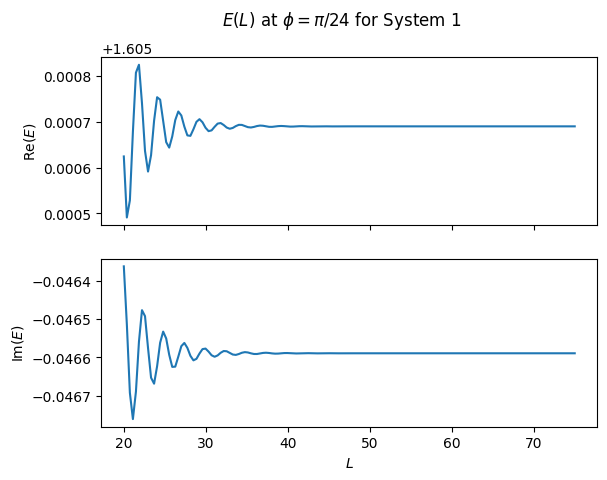

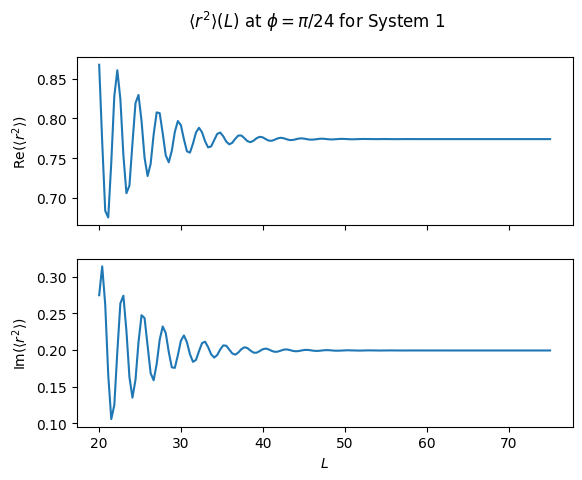

In [6]:
# plot E(L)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(Ls, np.real(energies))
ax2.plot(Ls, np.imag(energies))
ax1.set_ylabel(r"Re$(E)$")
ax2.set_ylabel(r"Im$(E)$")
ax2.set_xlabel(r"$L$")
fig.suptitle(r"$E(L)$ at $\phi=\pi/24$ for System 1")
plt.show()

# plot <r^2>(L)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(Ls, np.real(rrs))
ax2.plot(Ls, np.imag(rrs))
ax1.set_ylabel(r"Re$(\langle r^2\rangle)$")
ax2.set_ylabel(r"Im$(\langle r^2\rangle)$")
ax2.set_xlabel(r"$L$")
fig.suptitle(r"$\langle r^2\rangle(L)$ at $\phi=\pi/24$ for System 1")
plt.show()

### $E(\phi)$ and $(r^2)(\theta)$ at fixed $L$
We plot $E$ and $(r^2)$ across several $\phi$ in the "good" complex-scaling window, at a fixed, well-converged box size ($L=50$). Both observables are nearly $\phi$-dependent over a central subset of this window, consistent with the ABC theorem. But, they degrade near the edges, before the theoretical minimum and maximum are reached. 

Near $\phi_\text{min}$ approaches $\phi_\text{min}$, coupling with the finite-volume continuum states can contaminate the data. After complex scaling, $V(r)\propto \exp(-r^2\cos(2\theta))$. $As $\phi$ approaches $\phi_\text{max}$, the radial extent instability can contaminate the data before the theoretical maximum is actually reached.

In [7]:
# compute E and <r^2> as phi varies
# the ABC theorem says that this should be const.
phi_scan = 50
phi_lo, phi_hi = get_phi_bounds(res_guess)
phis = np.linspace(phi_lo, phi_hi, phi_scan)

results = linesweep_phi(
    dvr_system,
    res_guess,
    phis,
    observables
)
energies, rrs = results["energy"], results["rr"]

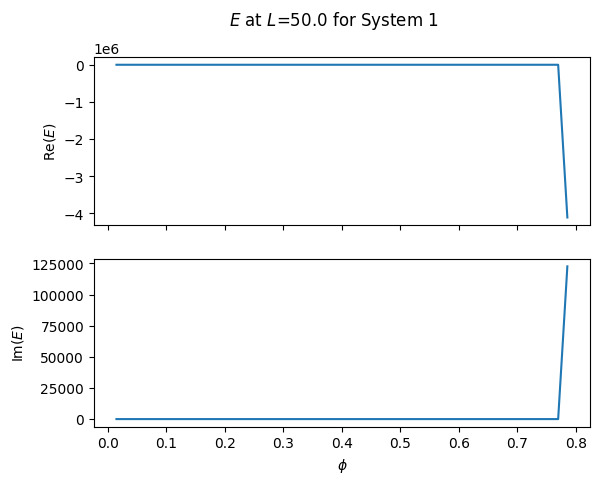

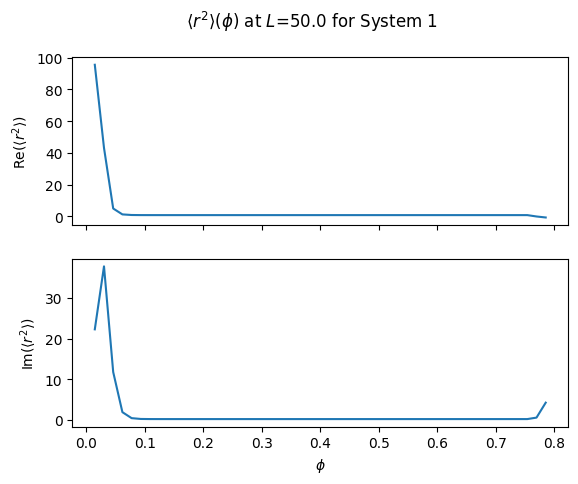

In [8]:
# plot <E>(phi)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(phis, np.real(energies))
ax2.plot(phis, np.imag(energies))
ax1.set_ylabel(r"Re$(E)$")
ax2.set_ylabel(r"Im$(E)$")
ax2.set_xlabel(r"$\phi$")
fig.suptitle(r"$E$ at $L$=50.0 for System 1")
plt.show()

# plot <r^2>(phi)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(phis, np.real(rrs))
ax2.plot(phis, np.imag(rrs))
ax1.set_ylabel(r"Re$(\langle r^2\rangle)$")
ax2.set_ylabel(r"Im$(\langle r^2\rangle)$")
ax2.set_xlabel(r"$\phi$")
fig.suptitle(r"$\langle r^2\rangle(\phi)$ at $L$=50.0 for System 1")
plt.show()

### Extend $\phi$ to the complex plane and analyze plateau regions using DVR.
Here, we use DVR to analyze how $E(\phi)$, $(r^2)(\phi)$, and $u_\phi(r)$ vary in complex $\theta$.

In [9]:
# phi region that looks good is phi = (0.2, 0.55)
phis_real = np.linspace(0.15, 0.55, 25)
phis_imag = np.linspace(-0.65, 0.4, 25)

observables = {"energies": obs_energy, "rrs": obs_rr}
results = gridsweep_phi(
    dvr_system,
    res_guess,
    phis_real,
    phis_imag,
    observables,
)
energies = results["energies"]
rrs = results["rrs"]

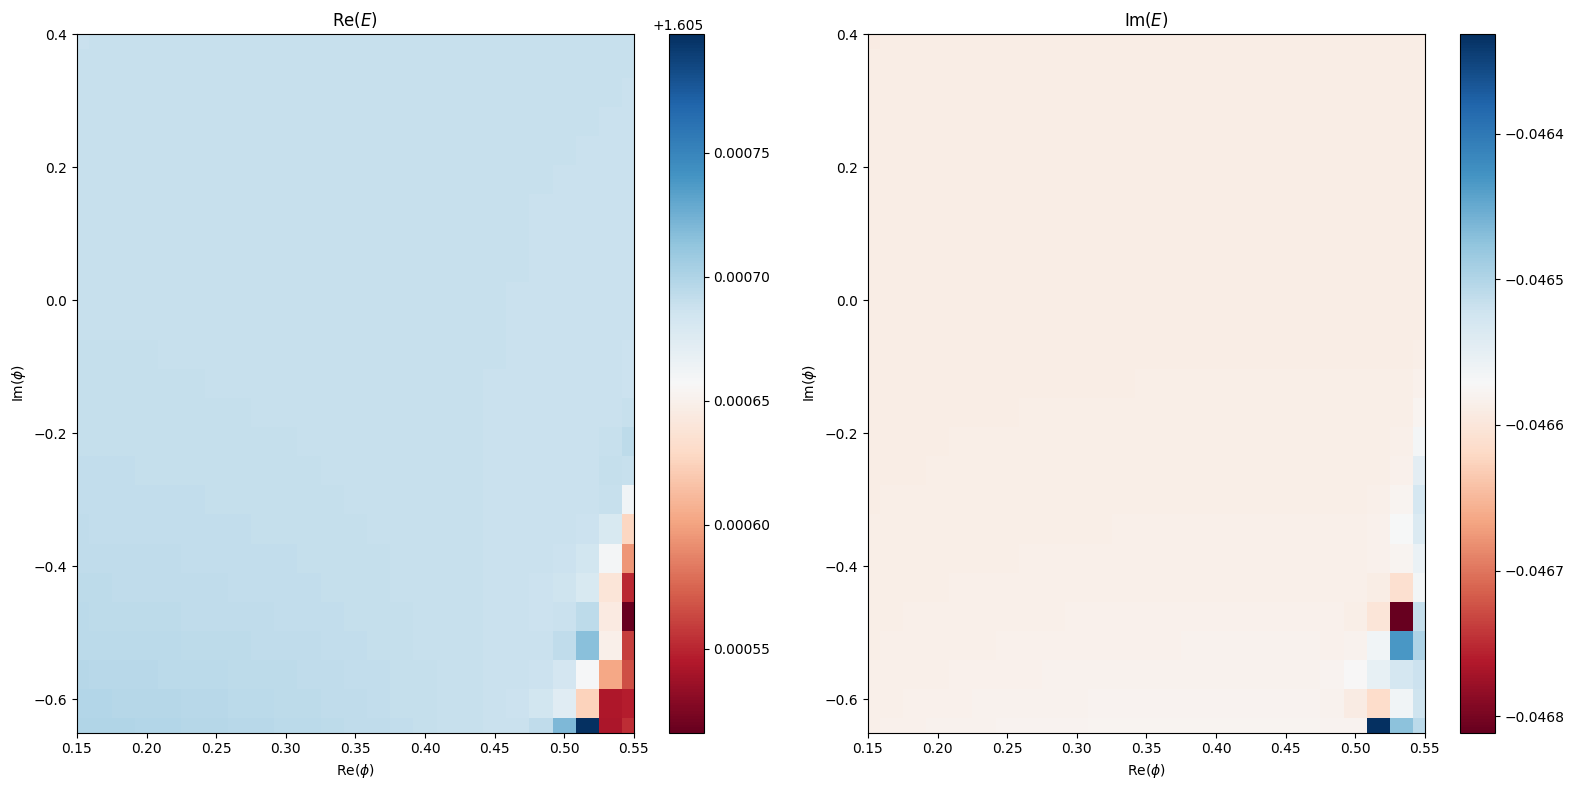

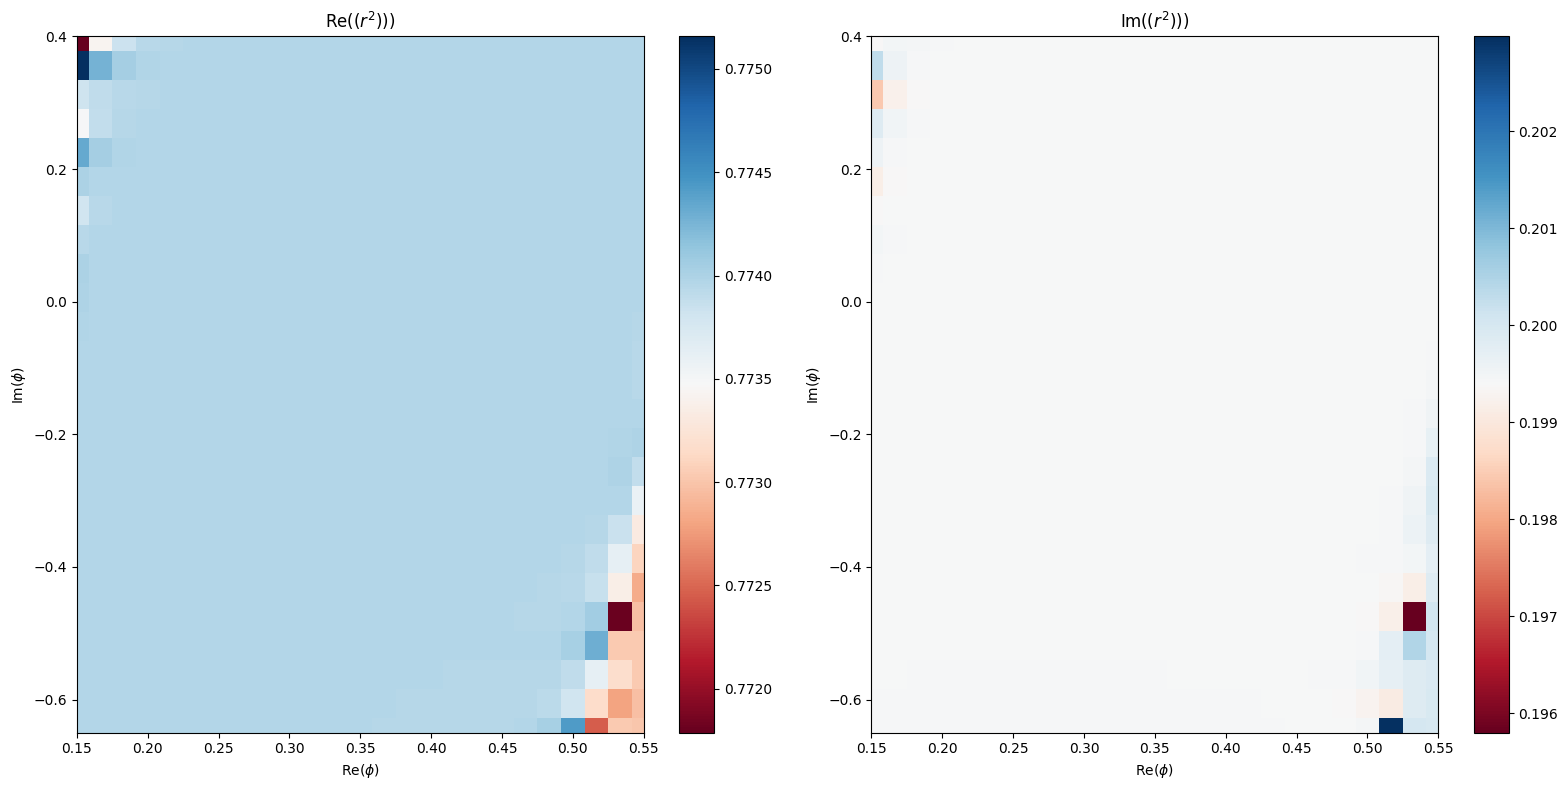

In [10]:
# energy plot
plot_data_over_phi_grid(phis_real, phis_imag, energies, title=r'$E$')
plt.show()

# rr plot
plot_data_over_phi_grid(phis_real, phis_imag, rrs, title=r'$(r^2)$)')
plt.show()

In [11]:
# show how states vary with varying Im(phi) for a fixed Re(phi)
x_plot = dvr_system.x_plot
states = np.zeros((len(x_plot), len(phis_imag)), dtype=np.complex128)
mid_phir = phis_real[len(phis_real)//2] # take the middle real value
for j in range(len(phis_imag)):
    phii = phis_imag[j]
    dvr_system.reset_rotation_angle(mid_phir + 1j*phii)
    _, state = dvr_system.closest_to_resonance(res_guess)
    states[:, j] = dvr_system.DVR_to_position_space(state[:, 0])        

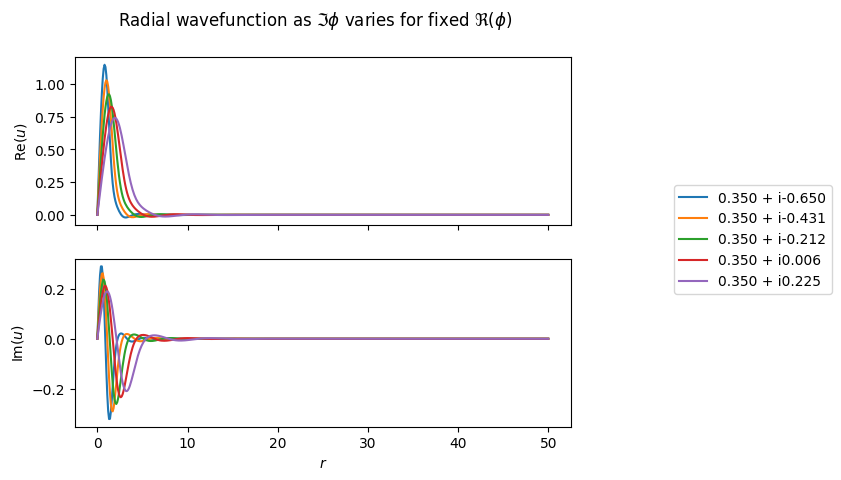

In [12]:
# plot the states as they vary in Im(phi) at fixed Re(phi)
fig, (axr, axi) = plt.subplots(2, 1, sharex=True)
skip = 5
for phii, state in zip(phis_imag[::skip], states.T[::skip]):
    axr.plot(x_plot, np.real(state), label=f"{mid_phir:.3f} + i{phii:.3f}")
    axi.plot(x_plot, np.imag(state), label=f"{mid_phir:.3f} + i{phii:.3f}")
axi.set_xlabel(rf"$r$")
axr.set_ylabel(rf"Re($u$)")
axi.set_ylabel(rf"Im($u$)")

fig.suptitle(r"Radial wavefunction as $\Im\phi$ varies for fixed $\Re(\phi)$")
handles, labels = axi.get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.05, 0.5))
plt.show()

### Automate search for best $(L, $mesh width$,\phi)$

In [13]:
# automate search for best L, n (mesh width) (scans over observables looking for plateaus).
# - run search_mesh_width over a suitable range of mesh widths for a few values of L (this gets expensive if L is large and mesh width is too small)
# - pick the best mesh width from the batch
# - run search_L at the winning mesh width for a suitable range of L
# - pick the winning L. This gives L_best, n_best
L_best, n_best = 50.0, 256
dvr_system = DVR(n_best, L_best, phi_guess, potential=gauss_s, l=0)

# using the new DVR guess, find the best range for training Re(phi)
# - run search_optimal_phirange to find the best range for Re(phi)
phi_best = np.pi/24
phi_real_range = [0.15, 0.55]

# using the winning real phis, scan over the imaginary component to find the best range for training Im(phi)
# - this isn't implemented in sweep_utils.py yet.
phi_imag_range = [-0.65, 0.4]

### Get training data over $\Re(\phi)$ and use that to compute references

In [14]:
num_real_training_points = 25

phi_real_train = np.linspace(phi_real_range[0], phi_real_range[1], num_real_training_points)
training_results = linesweep_phi(
    dvr_system,
    res_guess,
    phi_real_train,
    observables,
)
print_training_data(training_results)
real_res = get_reference(training_results["energies"]) 
real_rr = get_reference(training_results["rrs"])

Training energies: (1.60569 +- 0.00000) + i(-0.04659 +- 0.00000)
Training rrs: (0.77396 +- 0.00000) + i(0.19941 +- 0.00000)


### Train EC on complex $\theta$.
Here, we train EC on complex $\theta$ and compare the results to those of EC when trained only on real $\theta$. We make sure to account for the added precision expected by adding more training points. The good region of $\phi$ seems to be $\phi\in(0.15, 0.55) + i(-0.65, 0.4)$.

In [15]:
# get complex training set
nimag = 5
nreal = 5
phir = np.linspace(phi_real_range[0], phi_real_range[1], nreal)
phii = np.linspace(phi_imag_range[0], phi_imag_range[1], nimag)

phi_complex_train = []
for pr in phir:
    for pii in phii:
        phi_complex_train.append(pr + 1j*pii)
phi_complex_train = np.asarray(phi_complex_train, dtype=np.complex128)

# full training set
phi_train = np.concatenate((phi_real_train, phi_complex_train))

In [16]:
# train on complex rotation angles
dvr_system.reset_rotation_angle(phi_best)
ec_system = ECSystem(dvr_system, real_res)

ec_system.train(phi_train)
ec_system.construct_basis()

print(
    f"EC trained on {num_real_training_points+(nimag*nreal)} total training points.\n"
    f"{num_real_training_points} of the training points are pure real in [{phi_real_range[0]:.5f}, {phi_real_range[1]:.5f}].\n"
    f"{nimag*nreal} training points are complex: real resolution (Re(phi range), num real) = ([{phi_real_range[0]:.5f}, {phi_real_range[1]:.5f}], {nreal})\n"
    f"imaginary resolution (Im(phi range), num imag) = ([{phi_imag_range[0]:.5f}, {phi_imag_range[1]:.5f}], {nimag})\n"
)

EC trained on 50 total training points.
25 of the training points are pure real in [0.15000, 0.55000].
25 training points are complex: real resolution (Re(phi range), num real) = ([0.15000, 0.55000], 5)
imaginary resolution (Im(phi range), num imag) = ([-0.65000, 0.40000], 5)



### Predictions

#### Interpolation to $\phi$ in the good region

In [17]:
phi_predict = phi_best # np.median(np.real(phi_train)) + 1j*np.median(np.imag(phi_train))

observables = {"energy": predict_energy, "rr": predict_rr}
references = {"energy": real_res, "rr" : real_rr}
results = quick_predict(
    ec_system,
    phi_predict,
    observables,
    dvr_system,
    real_res,
)
print(f"-----------------------------------\n Results (Interpolation to phi={phi_predict.real:.3f}+i{phi_predict.imag:.3f}) \n ----------------------------------")
print_quick_predict(results)
print("-----------------------------------\n Residuals \n ------------------------")
print_quick_predict(quick_residuals(references, results))
print("-----------------------------------\n Relative Residuals \n ------------------------")
print_quick_predict(quick_residuals(references, results, relative=True))

-----------------------------------
 Results (Interpolation to phi=0.131+i0.000) 
 ----------------------------------
energy:1.60569 + i-0.04659
rr:0.77400 + i0.19951
-----------------------------------
 Residuals 
 ------------------------
energy:0.00000 + i0.00000
rr:0.00004 + i0.00009
-----------------------------------
 Relative Residuals 
 ------------------------
energy:0.00000 + i-0.00001
rr:0.00005 + i0.00047


#### Extrapolation to $\phi=0.0$

In [18]:
phi_predict = 0.0

observables = {"energy": predict_energy, "rr": predict_rr}
references = {"energy": real_res, "rr" : real_rr}
results = quick_predict(
    ec_system,
    phi_predict,
    observables,
    dvr_system,
    real_res,
)
print(f"-----------------------------------\n Results (Extrapolation to phi={phi_predict:.4f}) \n ----------------------------------")
print_quick_predict(results)
print("-----------------------------------\n Residuals \n ------------------------")
print_quick_predict(quick_residuals(references, results))
print("-----------------------------------\n Relative Residuals \n ------------------------")
print_quick_predict(quick_residuals(references, results, relative=True))

-----------------------------------
 Results (Extrapolation to phi=0.0000) 
 ----------------------------------
energy:1.60569 + i-0.04659
rr:0.77056 + i0.20109
-----------------------------------
 Residuals 
 ------------------------
energy:0.00000 + i0.00001
rr:0.00340 + i0.00168
-----------------------------------
 Relative Residuals 
 ------------------------
energy:0.00000 + i-0.00013
rr:0.00440 + i0.00842


#### Compare to performance when trained on just real values

In [19]:
# train on purely real rotation angles
dvr_system.reset_rotation_angle(phi_best)
ec_system = ECSystem(dvr_system, real_res)

# get training data
numt = num_real_training_points + nimag*nreal # train on the total number of training points from before
phi_train = np.linspace(phi_real_range[0], phi_real_range[1], numt, dtype=np.complex128)

ec_system.train(phi_train)
ec_system.construct_basis()

In [20]:
phi_predict = phi_best # np.median(np.real(phi_train)) + 1j*np.median(np.imag(phi_train))

observables = {"energy": predict_energy, "rr": predict_rr}
references = {"energy": real_res, "rr" : real_rr}
results = quick_predict(
    ec_system,
    phi_predict,
    observables,
    dvr_system,
    real_res,
)
print(f"-----------------------------------\n Results (Interpolation to phi={phi_predict.real:.3f}+i{phi_predict.imag:.3f}) \n ----------------------------------")
print_quick_predict(results)
print("-----------------------------------\n Residuals \n ------------------------")
print_quick_predict(quick_residuals(references, results))
print("-----------------------------------\n Relative Residuals \n ------------------------")
print_quick_predict(quick_residuals(references, results, relative=True))

-----------------------------------
 Results (Interpolation to phi=0.131+i0.000) 
 ----------------------------------
energy:1.60569 + i-0.04659
rr:0.77408 + i0.19909
-----------------------------------
 Residuals 
 ------------------------
energy:0.00000 + i0.00000
rr:0.00012 + i0.00032
-----------------------------------
 Relative Residuals 
 ------------------------
energy:0.00000 + i-0.00001
rr:0.00016 + i0.00159


In [21]:
phi_predict = 0.0

observables = {"energy": predict_energy, "rr": predict_rr}
references = {"energy": real_res, "rr" : real_rr}
results = quick_predict(
    ec_system,
    phi_predict,
    observables,
    dvr_system,
    real_res,
)
print(f"-----------------------------------\n Results (Extrapolation to phi={phi_predict:.4f}) \n ----------------------------------")
print_quick_predict(results)
print("-----------------------------------\n Residuals \n ------------------------")
print_quick_predict(quick_residuals(references, results))
print("-----------------------------------\n Relative Residuals \n ------------------------")
print_quick_predict(quick_residuals(references, results, relative=True))

-----------------------------------
 Results (Extrapolation to phi=0.0000) 
 ----------------------------------
energy:1.60565 + i-0.04662
rr:0.79010 + i0.18798
-----------------------------------
 Residuals 
 ------------------------
energy:0.00004 + i0.00003
rr:0.01614 + i0.01143
-----------------------------------
 Relative Residuals 
 ------------------------
energy:0.00002 + i-0.00072
rr:0.02086 + i0.05733
